# Voronoi Diagram from City Coordinates

This notebook loads the city list from `../docs/cities_de_50k.txt`, treats longitude as `x` and latitude as `y`, and plots a Voronoi diagram for the cities.

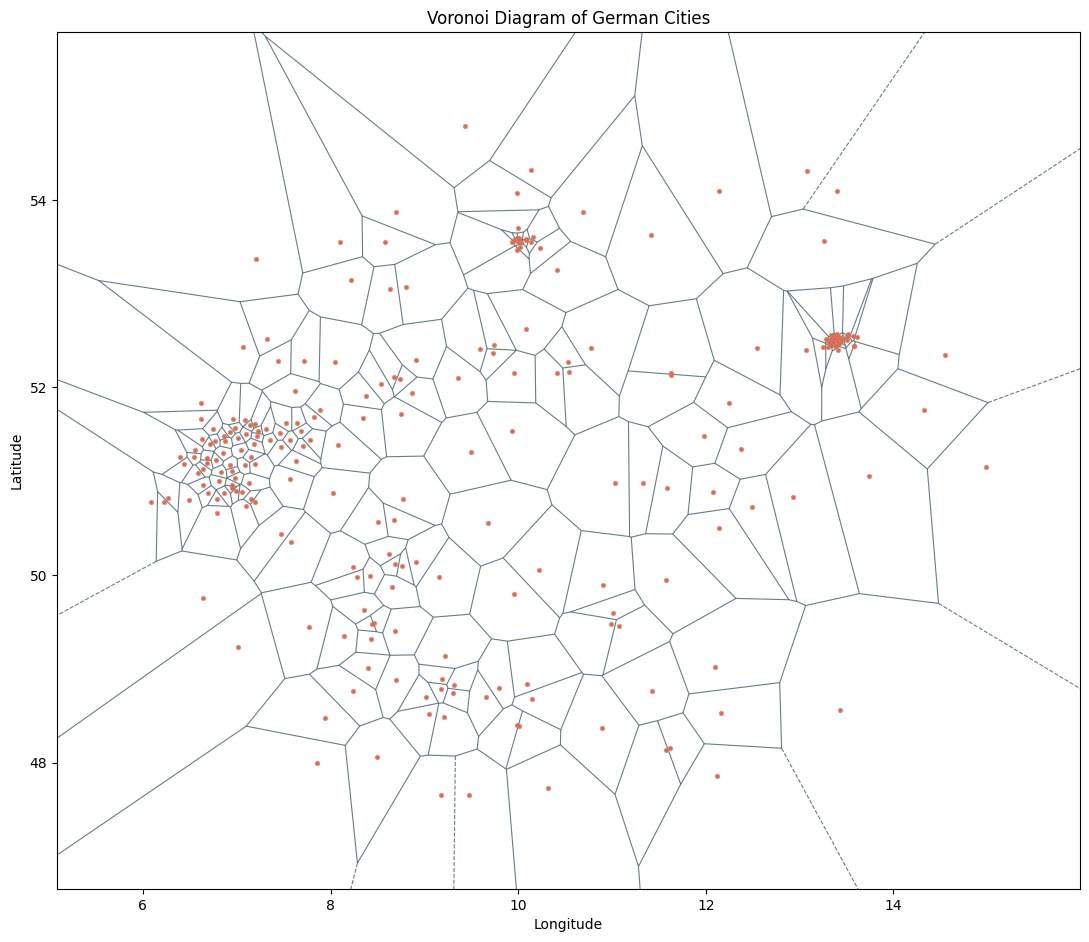

Loaded 236 cities from c:\Users\aksha\Downloads\Documents\FAU\project seminar\docs\cities_de_50k.txt


In [ ]:
import importlib.util
import subprocess
import sys
from pathlib import Path


def ensure_package(package_name: str) -> None:
    if importlib.util.find_spec(package_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


for package_name in ("matplotlib", "scipy", "pandas"):
    ensure_package(package_name)

import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d


def locate_cities_file() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "docs" / "cities_de_50k.txt"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find docs/cities_de_50k.txt")


cities_file = locate_cities_file()
cities = pd.read_csv(
    cities_file,
    header=None,
    names=["city", "latitude", "longitude"],
    skipinitialspace=True,
)

points = cities[["longitude", "latitude"]].to_numpy()
vor = Voronoi(points)

fig, ax = plt.subplots(figsize=(11, 12))
voronoi_plot_2d(
    vor,
    ax=ax,
    show_vertices=False,
    line_colors="#264653",
    line_width=0.8,
    line_alpha=0.7,
    point_size=2,
)

ax.scatter(points[:, 0], points[:, 1], s=8, color="#e76f51", alpha=0.7, zorder=3)
ax.set_title("Voronoi Diagram of German Cities")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(points[:, 0].min() - 1, points[:, 0].max() + 1)
ax.set_ylim(points[:, 1].min() - 1, points[:, 1].max() + 1)
plt.tight_layout()
plt.show()

print(f"Loaded {len(cities)} cities from {cities_file}")